# 01_overview_codes.ipynb

生成 `01_overview_lec.qmd` 中所需的全部图片。

**图片列表**

| 编号 | 文件名 | 内容 |
|------|------|------|
| fig01 | `limit_dep_intro_fig01_continuous.png` | 连续变量（正态）：基准对照 |
| fig02 | `limit_dep_intro_fig02_binary.png` | 二元 0/1 变量 |
| fig03 | `limit_dep_intro_fig03_ordered.png` | 有序多分类变量（满意度 1–5）|
| fig04 | `limit_dep_intro_fig04_corner.png` | 边角解（大量零值 + 连续正值）|
| fig05 | `limit_dep_intro_fig05_censored.png` | 归并数据（右归并）|
| fig06 | `limit_dep_intro_fig06_truncated.png` | 截断数据 vs 完整总体 |
| fig07 | `limit_dep_intro_fig07_count.png` | 计数数据（Poisson vs 负二项）|
| fig08 | `limit_dep_intro_fig08_selection.png` | 样本选择偏误（Heckman）|
| fig09 | `limit_dep_intro_fig09_overview.png` | 汇总：九种分布形态对比 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import expit
from scipy import stats
import warnings, os
warnings.filterwarnings('ignore')

# 中文字体（如有需要）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('./figs', exist_ok=True)

plt.rcParams.update({
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.2,
    'figure.dpi': 150,
})
BLUE, ORANGE, GRAY, GREEN = '#3B8BD4', '#D85A30', '#888780', '#3B9E6E'

def savefig(name):
    plt.savefig(f'./figs/{name}', bbox_inches='tight', dpi=150)
    plt.close()
    print(f'Saved: {name}')

# 统一随机种子
np.random.seed(2025)
N = 2000
print('环境准备完成')

环境准备完成


---
## fig01：连续变量（正态）——基准对照

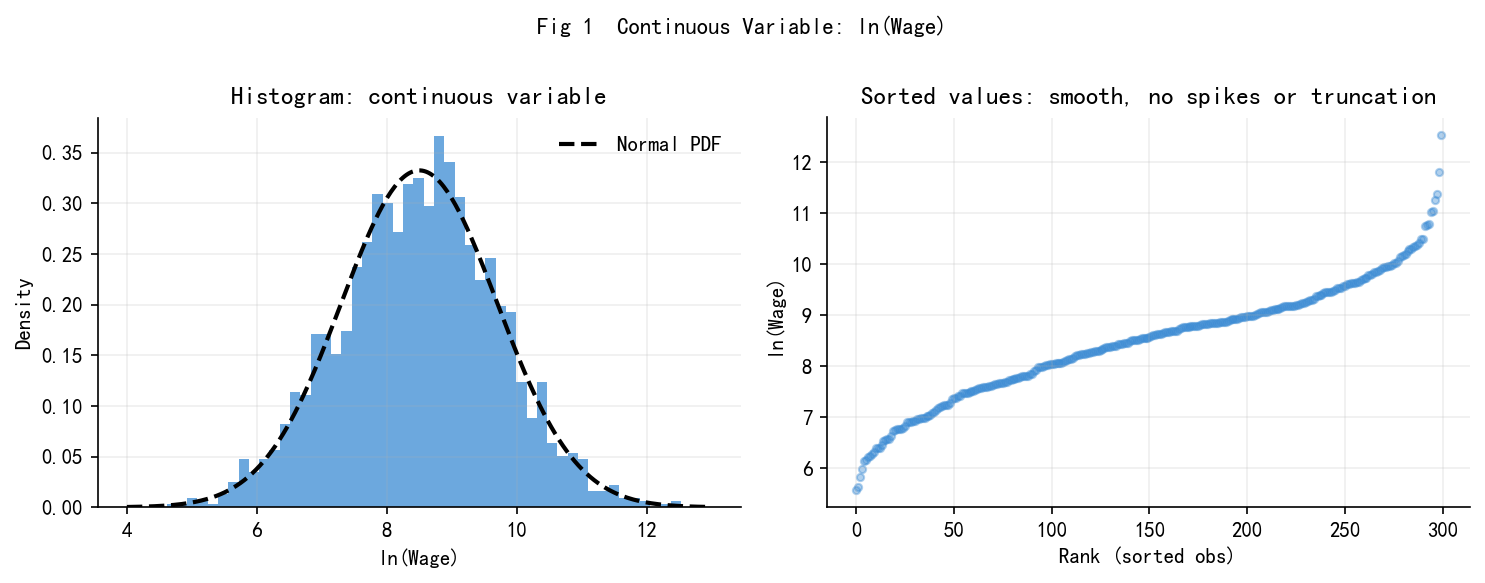

Saved: limit_dep_intro_fig01_continuous.png


In [7]:
wage = np.random.normal(8.5, 1.2, N)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

ax = axes[0]
ax.hist(wage, bins=50, color=BLUE, alpha=0.75, edgecolor='none', density=True)
xs = np.linspace(4, 13, 300)
ax.plot(xs, stats.norm.pdf(xs, 8.5, 1.2), color='black', lw=1.5, ls='--', label='Normal PDF')
ax.set_xlabel('ln(Wage)')
ax.set_ylabel('Density')
ax.set_title('Histogram: continuous variable')
ax.legend(frameon=False)

ax = axes[1]
idx = np.arange(300)
ax.scatter(idx, np.sort(wage[:300]), alpha=0.4, s=12, color=BLUE)
ax.set_xlabel('Rank (sorted obs)')
ax.set_ylabel('ln(Wage)')
ax.set_title('Sorted values: smooth, no spikes or truncation')

plt.suptitle('Fig 1  Continuous Variable: ln(Wage)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()
savefig('limit_dep_intro_fig01_continuous.png')



---
## fig02：二元 0/1 变量

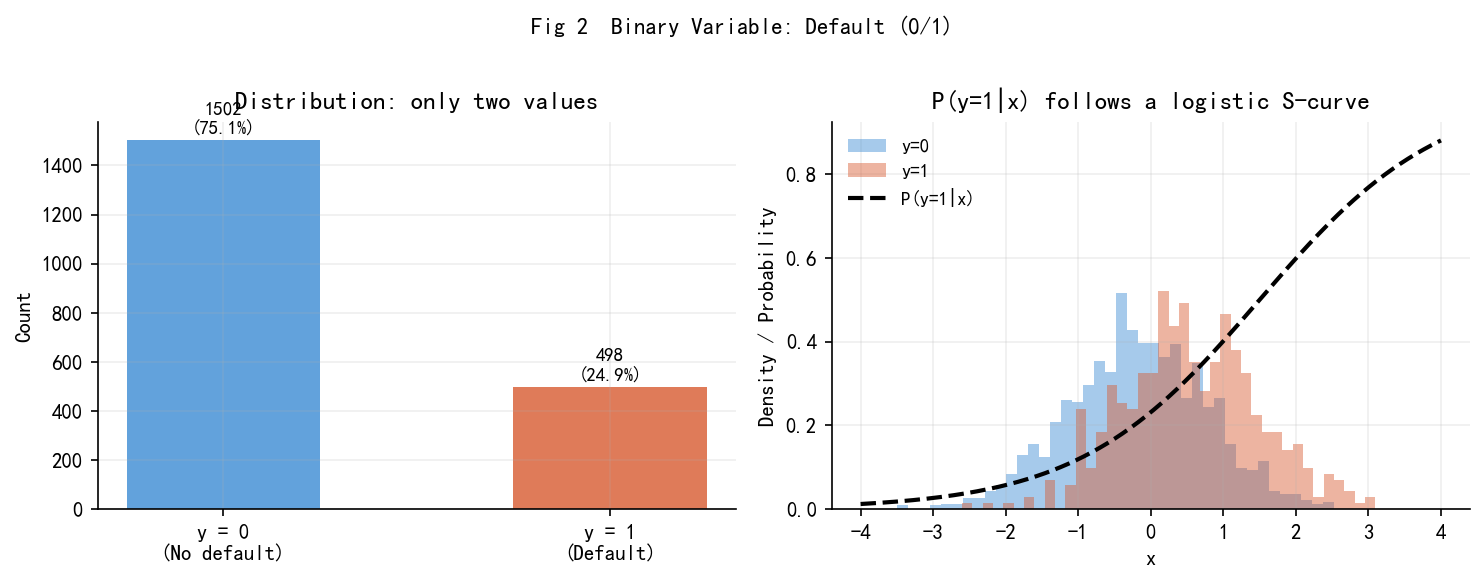

Saved: limit_dep_intro_fig02_binary.png
违约率: 24.9%


In [6]:
x_bin = np.random.normal(0, 1, N)
p_bin = expit(-1.2 + 0.8 * x_bin)
y_bin = (np.random.uniform(0, 1, N) < p_bin).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# 左图：分布条形图
ax = axes[0]
counts = pd.Series(y_bin).value_counts().sort_index()
bars = ax.bar([0, 1], counts.values, color=[BLUE, ORANGE], alpha=0.8, width=0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['y = 0\n(No default)', 'y = 1\n(Default)'])
ax.set_ylabel('Count')
ax.set_title('Distribution: only two values')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val}\n({val/N:.1%})', ha='center', va='bottom', fontsize=9)

# 右图：P(y=1|x) 的 S 型曲线
ax = axes[1]
d0 = x_bin[y_bin == 0]
d1 = x_bin[y_bin == 1]
ax.hist(d0, bins=40, alpha=0.45, color=BLUE,   label='y=0', density=True)
ax.hist(d1, bins=40, alpha=0.45, color=ORANGE, label='y=1', density=True)
xs2 = np.linspace(-4, 4, 300)
ax.plot(xs2, expit(-1.2 + 0.8*xs2), color='black', lw=1.5, ls='--',
        label='P(y=1|x)')
ax.set_xlabel('x')
ax.set_ylabel('Density / Probability')
ax.set_title('P(y=1|x) follows a logistic S-curve')
ax.legend(frameon=False, fontsize=9)

plt.suptitle('Fig 2  Binary Variable: Default (0/1)', fontsize=11, y=1.01)
plt.tight_layout()
#展示图片
plt.show()
savefig('limit_dep_intro_fig02_binary.png')

print(f'违约率: {y_bin.mean():.1%}')

---
## fig03：有序多分类变量（满意度 1–5）

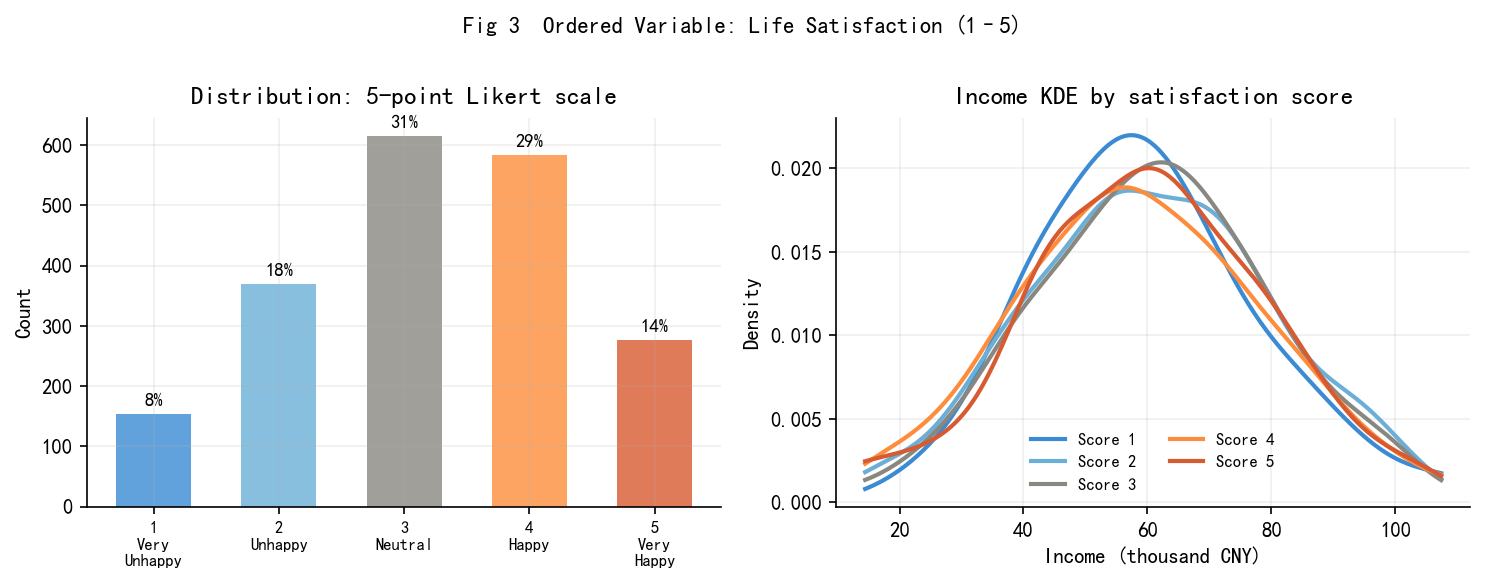

Saved: limit_dep_intro_fig03_ordered.png


In [12]:
y_ord  = np.random.choice([1, 2, 3, 4, 5], N, p=[0.08, 0.18, 0.32, 0.28, 0.14])
income = np.random.normal(60000, 20000, N)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# 左图：评分分布
ax = axes[0]
counts_ord = pd.Series(y_ord).value_counts().sort_index()
xlabels = ['1\nVery\nUnhappy', '2\nUnhappy', '3\nNeutral', '4\nHappy', '5\nVery\nHappy']
colors5  = [BLUE, '#6baed6', GRAY, '#fd8d3c', ORANGE]
bars = ax.bar(range(1, 6), counts_ord.values, color=colors5, alpha=0.8, width=0.6)
ax.set_xticks(range(1, 6))
ax.set_xticklabels(xlabels, fontsize=8)
ax.set_ylabel('Count')
ax.set_title('Distribution: 5-point Likert scale')
for bar, val in zip(bars, counts_ord.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val/N:.0%}', ha='center', va='bottom', fontsize=9)

# 右图：各评分组内的收入分布（核密度函数）
ax = axes[1]
x_grid = np.linspace(np.percentile(income, 1), np.percentile(income, 99), 300) / 1000

for cat, col in zip([1, 2, 3, 4, 5], colors5):
    vals = income[y_ord == cat] / 1000
    if len(vals) > 1:
        kde = stats.gaussian_kde(vals)
        ax.plot(x_grid, kde(x_grid), color=col, lw=1.5, label=f'Score {cat}')

ax.set_xlabel('Income (thousand CNY)')
ax.set_ylabel('Density')
ax.set_title('Income KDE by satisfaction score')
ax.legend(frameon=False, fontsize=8, ncol=2)

plt.suptitle('Fig 3  Ordered Variable: Life Satisfaction (1–5)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()
savefig('limit_dep_intro_fig03_ordered.png')

---
## fig04：边角解数据（大量零值 + 连续正值）

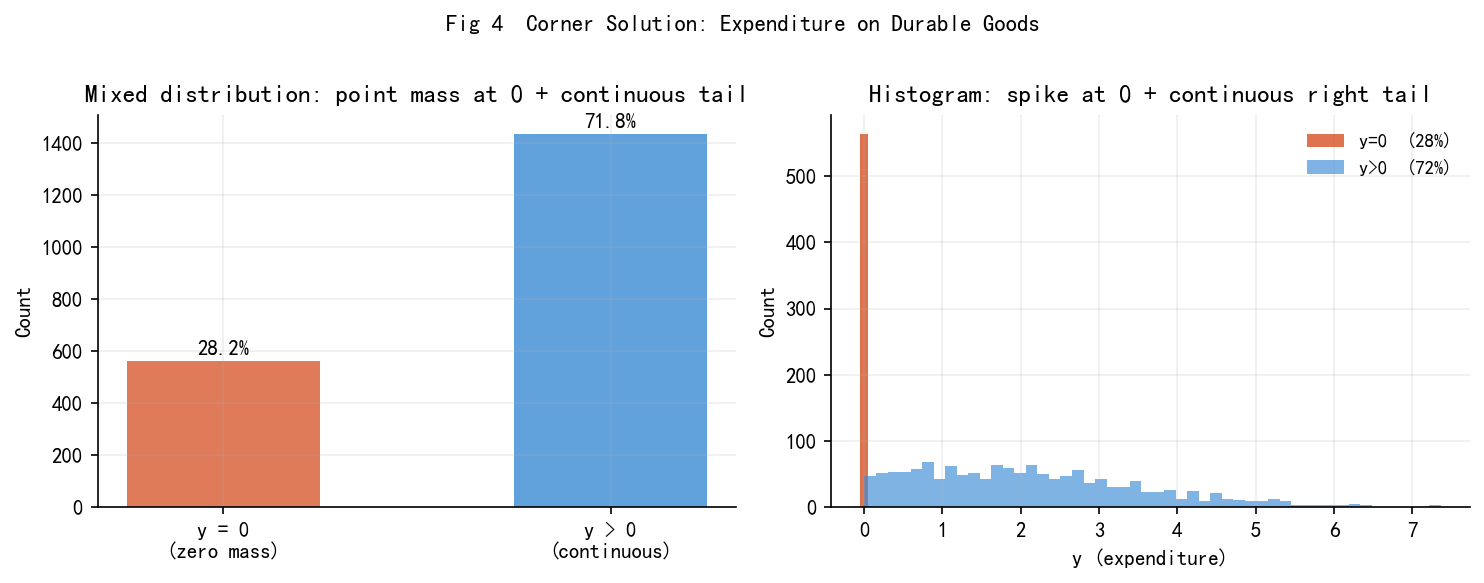

Saved: limit_dep_intro_fig04_corner.png
零值比例: 28.2%  正值均值: 2.14


In [11]:
# DGP: y = max(0, y*),  y* ~ N(1.2, 2.0)
ystar_c  = np.random.normal(1.2, 2.0, N)
y_corner = np.maximum(0, ystar_c)
zero_n   = (y_corner == 0).sum()
pos_n    = (y_corner > 0).sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# 左图：质量点 vs 连续部分
ax = axes[0]
bars = ax.bar(['y = 0\n(zero mass)', 'y > 0\n(continuous)'],
              [zero_n, pos_n], color=[ORANGE, BLUE], alpha=0.8, width=0.5)
ax.set_ylabel('Count')
ax.set_title('Mixed distribution: point mass at 0 + continuous tail')
for bar, val in zip(bars, [zero_n, pos_n]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val/N:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 右图：完整直方图（展示零堆积 + 连续尾部）
ax = axes[1]
ax.hist(y_corner[y_corner == 0], bins=1, range=(-0.05, 0.05),
        color=ORANGE, alpha=0.85, label=f'y=0  ({zero_n/N:.0%})')
ax.hist(y_corner[y_corner > 0],  bins=50,
        color=BLUE,   alpha=0.65, label=f'y>0  ({pos_n/N:.0%})')
ax.set_xlabel('y (expenditure)')
ax.set_ylabel('Count')
ax.set_title('Histogram: spike at 0 + continuous right tail')
ax.legend(frameon=False, fontsize=9)

plt.suptitle('Fig 4  Corner Solution: Expenditure on Durable Goods', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()
savefig('limit_dep_intro_fig04_corner.png')

print(f'零值比例: {zero_n/N:.1%}  正值均值: {y_corner[y_corner>0].mean():.2f}')

---
## fig05：归并数据（右归并）

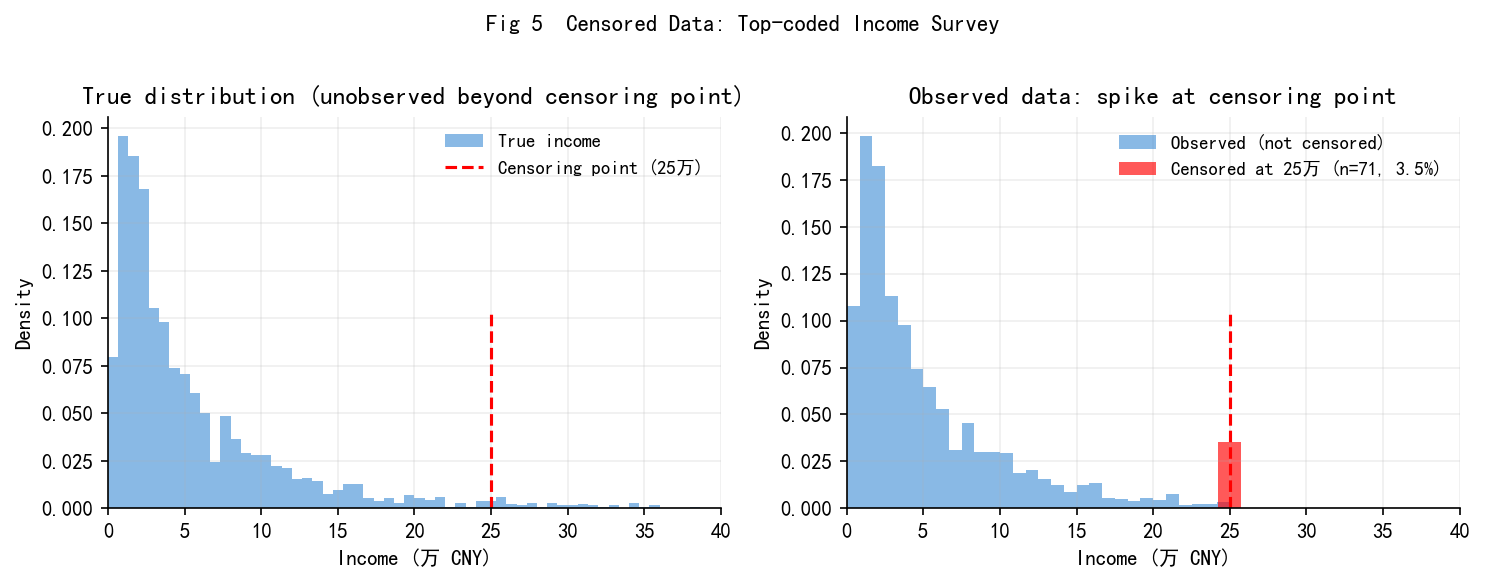

Saved: limit_dep_intro_fig05_censored.png
归并比例: 3.5%


In [41]:
# 真实收入（对数正态）；归并点：25 万元
income_true = np.random.lognormal(10.5, 1.1, N)   # 单位：元
CENS_POINT  = 250000                              # 25 万元
income_cens = np.minimum(income_true, CENS_POINT)
is_censored = income_true > CENS_POINT

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# 左图：真实分布（不可观测）
ax = axes[0]
ax.hist(income_true / 1e4, bins=60, color=BLUE, alpha=0.6,
        label='True income', density=True, range=(0, 40))
ax.axvline(CENS_POINT / 1e4, color='red', lw=1.5, ls='--', ymin=0, ymax=0.5,
           label=f'Censoring point ({CENS_POINT/1e4:.0f}万)')
ax.set_xlabel('Income (万 CNY)')
ax.set_ylabel('Density')
ax.set_title('True distribution (unobserved beyond censoring point)')
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(0, 40)

# 右图：观测到的归并数据
ax = axes[1]
ax.hist(income_cens[~is_censored] / 1e4, bins=60, color=BLUE,
        alpha=0.6, density=True, range=(0, 50), label='Observed (not censored)')
cens_n = is_censored.sum()
# 用一根高竖条代表归并点处的质量堆积
ax.bar(
    [CENS_POINT / 1e4],
    [cens_n / N * 1],
    width=1.5,
    color='red',
    alpha=0.65,
    label=f'Censored at 25万 (n={cens_n}, {cens_n/N:.1%})'
)
ax.axvline(CENS_POINT / 1e4, color='red', lw=1.5, ls='--', ymin=0, ymax=0.5)
ax.set_xlabel('Income (万 CNY)')
ax.set_ylabel('Density')
ax.set_title('Observed data: spike at censoring point')
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(0, 40)

plt.suptitle('Fig 5  Censored Data: Top-coded Income Survey', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()
savefig('limit_dep_intro_fig05_censored.png')

print(f'归并比例: {is_censored.mean():.1%}')

---
## fig06：截断数据 vs 完整总体

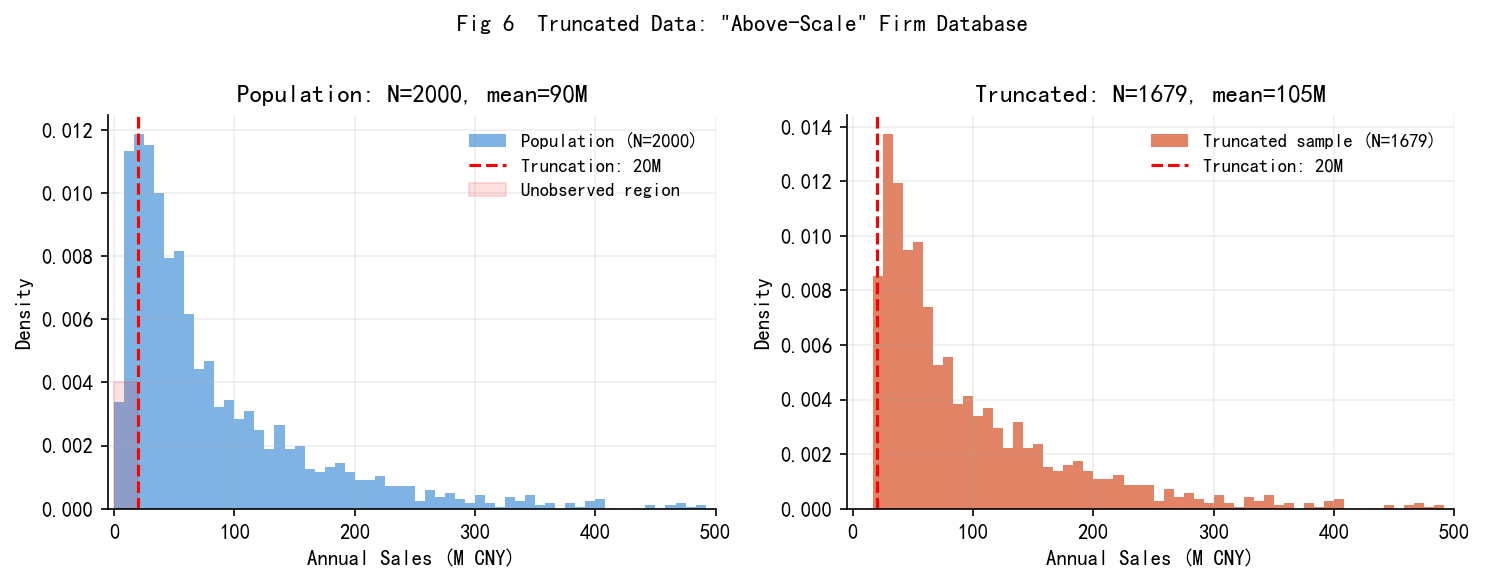

Saved: limit_dep_intro_fig06_truncated.png
总体N=2000, 截断后N=1679, 损失=16.0%
总体均值=90M, 截断后均值=105M


In [44]:
# 总体：所有企业（含小企业）；截断点：年销售额 >= 20 百万
sales_pop = np.random.lognormal(4.0, 1.0, N)     # 单位：百万元
TRUNC     = 20
sales_obs = sales_pop[sales_pop > TRUNC]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# 左图：总体分布
ax = axes[0]
ax.hist(sales_pop, bins=60, color=BLUE, alpha=0.65,
        range=(0, 500), density=True, label=f'Population (N={N})')
ax.axvline(TRUNC, color='red', lw=1.5, ls='--', label=f'Truncation: {TRUNC}M')
ax.fill_betweenx([0, 0.004], 0, TRUNC, color='red', alpha=0.12,
                 label='Unobserved region')
ax.set_xlabel('Annual Sales (M CNY)')
ax.set_ylabel('Density')
ax.set_title(f'Population: N={N}, mean={sales_pop.mean():.0f}M')
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(-5, 500)

# 右图：截断样本
ax = axes[1]
ax.hist(sales_obs, bins=60, color=ORANGE, alpha=0.75,
        range=(0, 500), density=True, label=f'Truncated sample (N={len(sales_obs)})')
ax.axvline(TRUNC, color='red', lw=1.5, ls='--', label=f'Truncation: {TRUNC}M')
ax.set_xlabel('Annual Sales (M CNY)')
ax.set_ylabel('Density')
ax.set_title(f'Truncated: N={len(sales_obs)}, mean={sales_obs.mean():.0f}M')
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(-5, 500)

plt.suptitle('Fig 6  Truncated Data: "Above-Scale" Firm Database', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()
savefig('limit_dep_intro_fig06_truncated.png')

print(f'总体N={N}, 截断后N={len(sales_obs)}, 损失={1-len(sales_obs)/N:.1%}')
print(f'总体均值={sales_pop.mean():.0f}M, 截断后均值={sales_obs.mean():.0f}M')

---
## fig07：计数数据（Poisson vs 负二项）

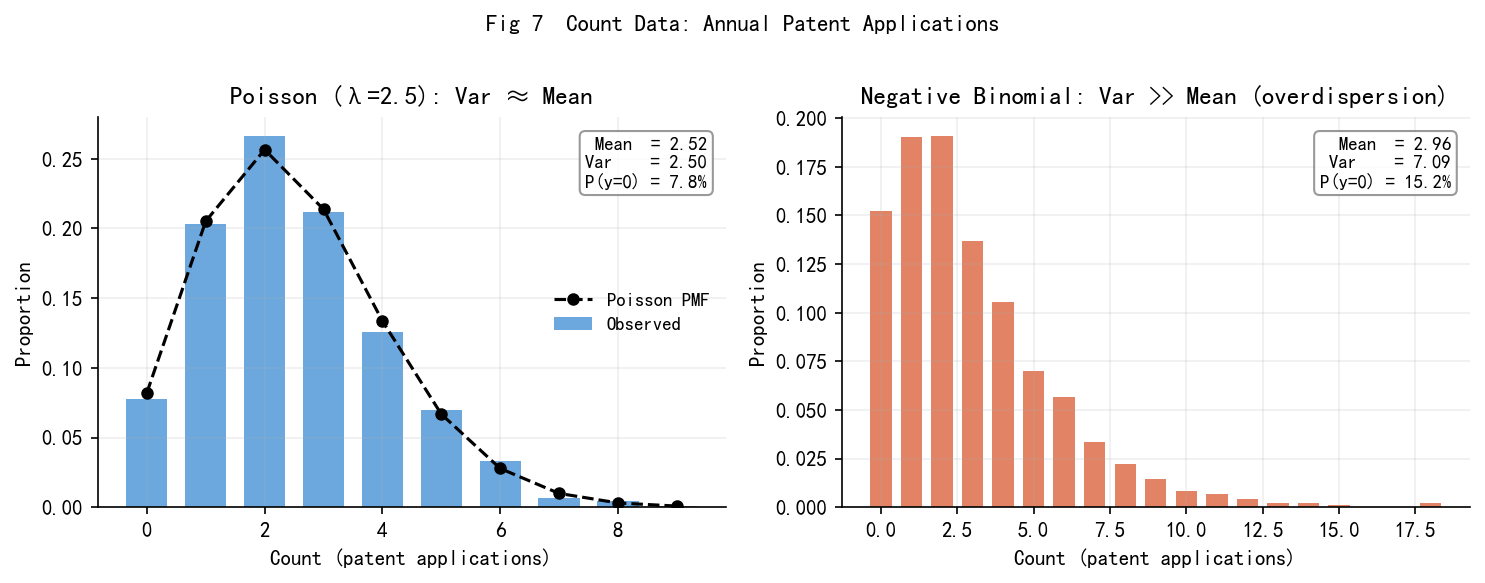

Saved: limit_dep_intro_fig07_count.png


In [17]:
# Poisson（等散度）：λ=2.5
patents_pois = np.random.poisson(2.5, N)
# 负二项（过度分散）：E≈3, Var≈8
patents_nb   = np.random.negative_binomial(2, 0.40, N)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

for ax, data, title, col, show_pmf in [
    (axes[0], patents_pois, 'Poisson (λ=2.5): Var ≈ Mean', BLUE, True),
    (axes[1], patents_nb,   'Negative Binomial: Var >> Mean (overdispersion)', ORANGE, False)
]:
    max_val = min(data.max(), 20)
    vals, cnts = np.unique(data[data <= max_val], return_counts=True)
    ax.bar(vals, cnts / N, color=col, alpha=0.75, width=0.7, label='Observed')
    if show_pmf:
        xs = np.arange(0, max_val+1)
        ax.plot(xs, stats.poisson.pmf(xs, 2.5), 'ko--', ms=5, lw=1.5, label='Poisson PMF')
        ax.legend(frameon=False, fontsize=9)
    ax.set_xlabel('Count (patent applications)')
    ax.set_ylabel('Proportion')
    ax.set_title(title)
    info = (f'Mean  = {data.mean():.2f}\n'
            f'Var    = {data.var():.2f}\n'
            f'P(y=0) = {(data==0).mean():.1%}')
    ax.text(0.97, 0.95, info, transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

plt.suptitle('Fig 7  Count Data: Annual Patent Applications', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()
savefig('limit_dep_intro_fig07_count.png')

---
## fig08：样本选择偏误（Heckman）

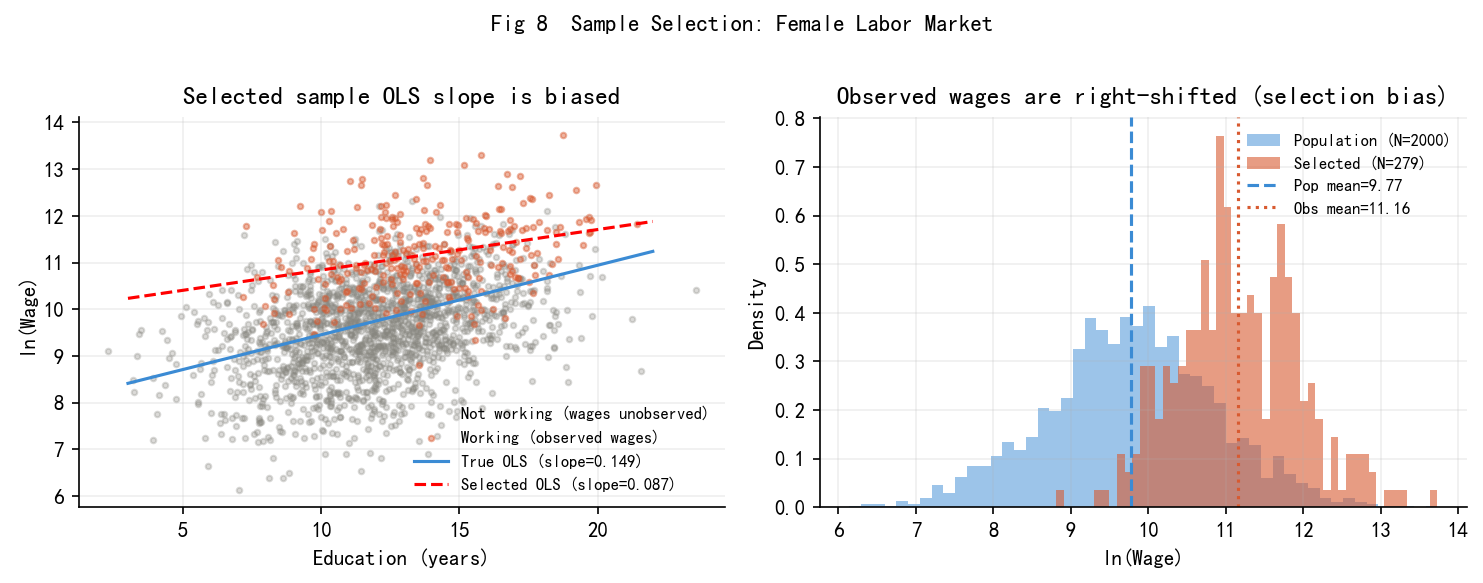

Saved: limit_dep_intro_fig08_selection.png
就业率: 14.0%
总体斜率: 0.1486  观测斜率: 0.0866  偏误: -0.0620


In [47]:
# DGP: 教育 → 工资（结果方程）；教育 + 非劳动收入 + 不可观测项 → 是否就业（选择方程）
# 让选择方程显式依赖 u2，并提高相关性，偏误会更明显
seed = 42
np.random.seed(seed)
educ = np.random.normal(12, 3, N)
nonlab_inc = np.random.normal(6, 2, N)  # 非劳动收入（越高越不工作）

e1 = np.random.normal(0, 1, N)
e2 = np.random.normal(0, 1, N)
rho = 0.9
u1 = e1
u2 = rho * e1 + np.sqrt(1 - rho**2) * e2   # 与 u1 高相关

# 结果方程（潜在工资）
wage_lat = 8.0 + 0.15 * educ + u1

# 选择方程（关键：包含 u2）
work_latent = -1.8 + 0.18 * educ - 0.35 * nonlab_inc + 1.4 * u2
work = (work_latent > 0).astype(int)

wage_obs = wage_lat[work == 1]
educ_obs = educ[work == 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# 左图：散点图 + 两条 OLS 线
ax = axes[0]
ax.scatter(educ[work == 0], wage_lat[work == 0], alpha=0.3, s=7,
           color=GRAY, label='Not working (wages unobserved)')
ax.scatter(educ_obs, wage_obs, alpha=0.45, s=7,
           color=ORANGE, label='Working (observed wages)')
m_pop = np.polyfit(educ, wage_lat, 1)
m_obs = np.polyfit(educ_obs, wage_obs, 1)
xs_e = np.linspace(3, 22, 100)
ax.plot(xs_e, np.polyval(m_pop, xs_e), color=BLUE, lw=1.5,
        label=f'True OLS (slope={m_pop[0]:.3f})')
ax.plot(xs_e, np.polyval(m_obs, xs_e), color='red', lw=1.5, ls='--',
        label=f'Selected OLS (slope={m_obs[0]:.3f})')
ax.set_xlabel('Education (years)')
ax.set_ylabel('ln(Wage)')
ax.set_title('Selected sample OLS slope is biased')
ax.legend(frameon=False, fontsize=8)

# 右图：工资分布对比
ax = axes[1]
ax.hist(wage_lat, bins=50, color=BLUE, alpha=0.5, density=True,
        label=f'Population (N={N})')
ax.hist(wage_obs, bins=50, color=ORANGE, alpha=0.6, density=True,
        label=f'Selected (N={work.sum()})')
ax.axvline(wage_lat.mean(), color=BLUE, lw=1.5, ls='--',
           label=f'Pop mean={wage_lat.mean():.2f}')
ax.axvline(wage_obs.mean(), color=ORANGE, lw=1.5, ls=':',
           label=f'Obs mean={wage_obs.mean():.2f}')
ax.set_xlabel('ln(Wage)')
ax.set_ylabel('Density')
ax.set_title('Observed wages are right-shifted (selection bias)')
ax.legend(frameon=False, fontsize=8)

plt.suptitle('Fig 8  Sample Selection: Female Labor Market', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()
savefig('limit_dep_intro_fig08_selection.png')

print(f'就业率: {work.mean():.1%}')
print(f'总体斜率: {m_pop[0]:.4f}  观测斜率: {m_obs[0]:.4f}  偏误: {m_obs[0]-m_pop[0]:+.4f}')

---
## fig09：汇总对比图（3×3 小图）

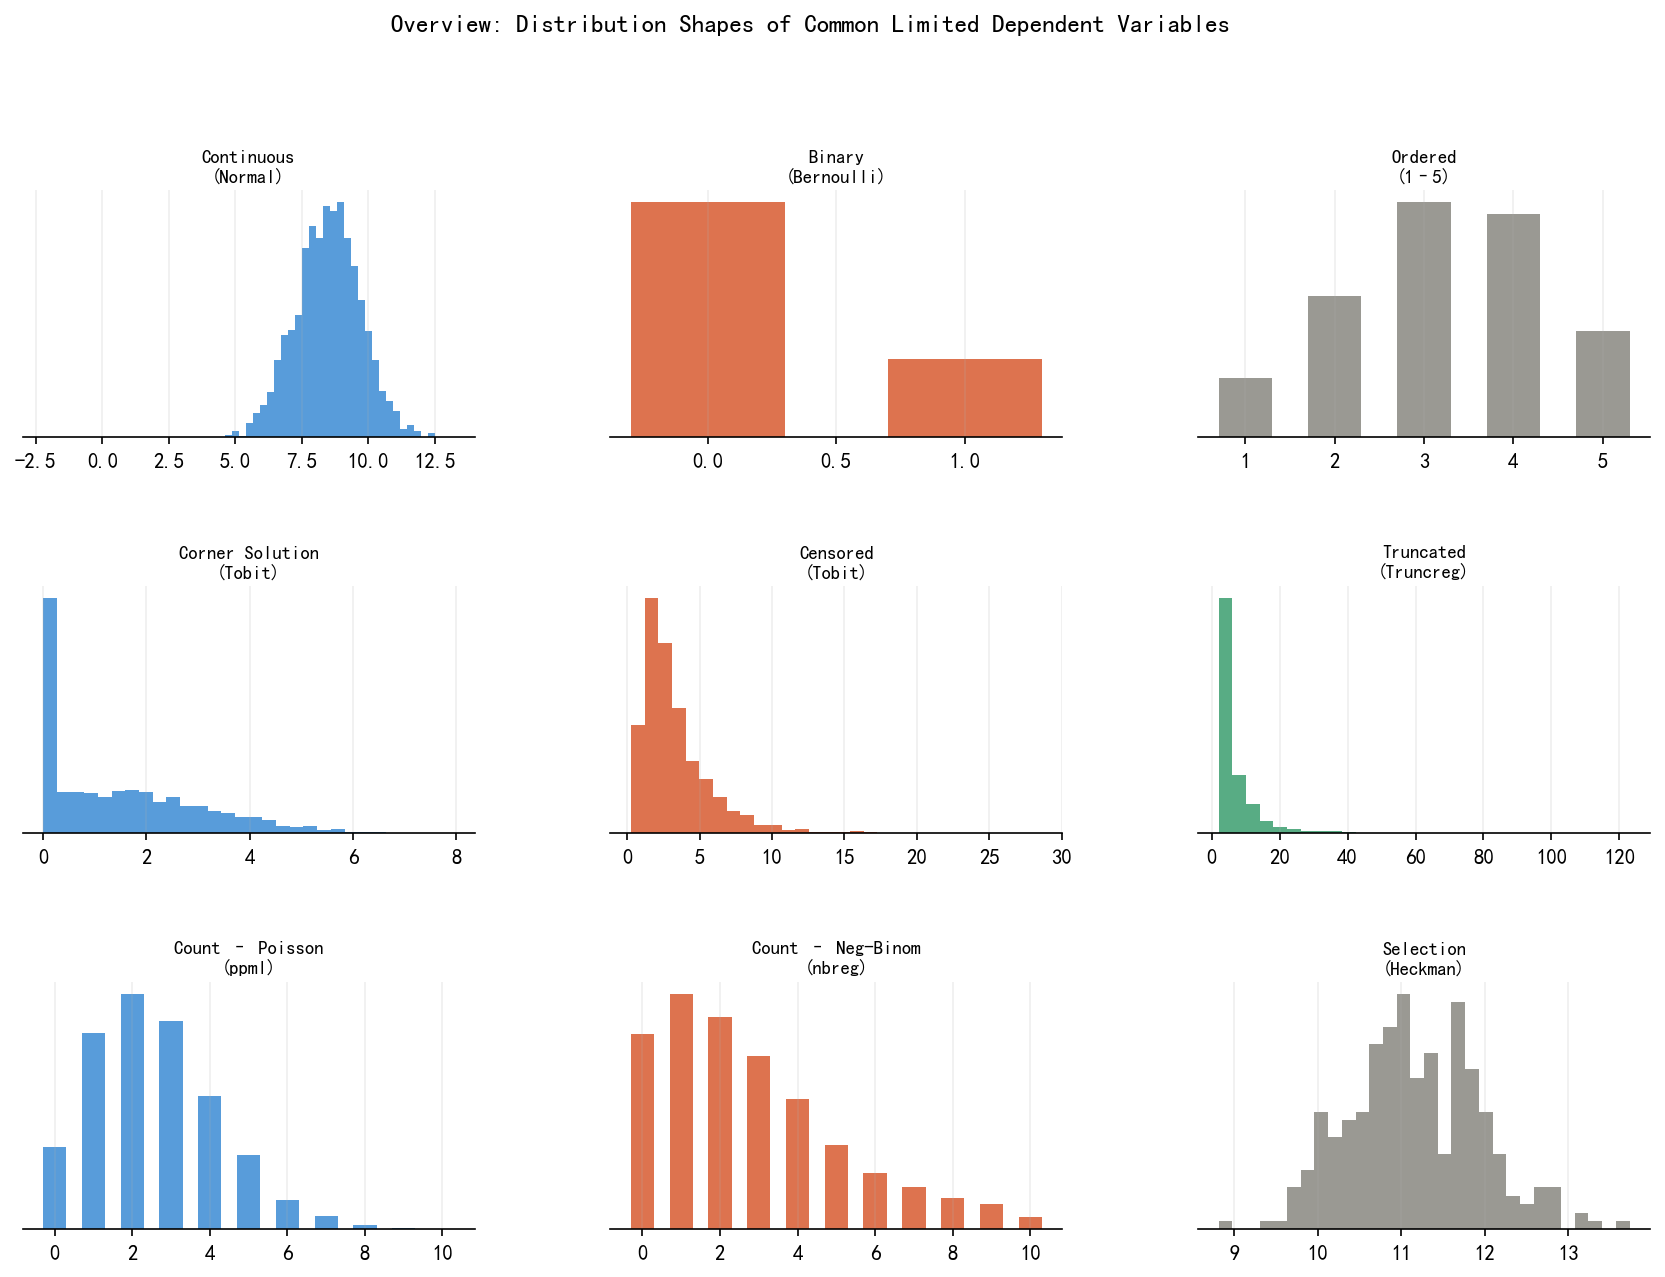

Saved: limit_dep_intro_fig09_overview.png
所有图片生成完成！


In [48]:
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.60, wspace=0.30)

# 复用前面生成的数据
ystar_c2  = np.random.normal(1.2, 2.0, N)
y_corner2 = np.maximum(0, ystar_c2)
income_true2 = np.random.lognormal(10.2, 0.7, N)
income_cens2 = np.minimum(income_true2, 300000)
sales_pop2 = np.random.lognormal(3.0, 1.2, N)
sales_obs2 = sales_pop2[sales_pop2 > 20]
patents2   = np.random.poisson(2.5, N)
patents_nb2= np.random.negative_binomial(2, 0.40, N)

panels = [
    ('Continuous\n(Normal)',         wage,            BLUE,   'hist', (-3, 14)),
    ('Binary\n(Bernoulli)',          y_bin,           ORANGE, 'bar',  None),
    ('Ordered\n(1–5)',               y_ord,           GRAY,   'bar',  None),
    ('Corner Solution\n(Tobit)',     y_corner2,       BLUE,   'hist', None),
    ('Censored\n(Tobit)',            income_cens2/1e4,ORANGE, 'hist', None),
    ('Truncated\n(Truncreg)',        sales_obs2/10,   GREEN,  'hist', None),
    ('Count – Poisson\n(ppml)',      patents2,        BLUE,   'bar',  None),
    ('Count – Neg-Binom\n(nbreg)',   patents_nb2,     ORANGE, 'bar',  None),
    ('Selection\n(Heckman)',         wage_obs,        GRAY,   'hist', None),
]

for idx, (title, data, col, kind, xlim) in enumerate(panels):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    if kind == 'hist':
        ax.hist(data, bins=30, color=col, alpha=0.85, edgecolor='none', density=True)
    else:
        max_v = min(int(data.max()), 10) if data.max() > 6 else int(data.max())
        vals, cnts = np.unique(data[data <= max_v], return_counts=True)
        ax.bar(vals, cnts / len(data), color=col, alpha=0.85, width=0.6)
    if xlim:
        ax.set_xlim(xlim)
    ax.set_title(title, fontsize=9, fontweight='bold', pad=4)
    ax.set_yticks([])
    for sp in ['top', 'right', 'left']:
        ax.spines[sp].set_visible(False)

fig.suptitle(
    'Overview: Distribution Shapes of Common Limited Dependent Variables',
    fontsize=12, y=1.01
)
plt.show()
savefig('limit_dep_intro_fig09_overview.png')
print('所有图片生成完成！')

---
## 附：数据生成参数汇总

| 图片 | 数据类型 | DGP 设定 |
|------|------|------|
| fig01 | 连续 | ln(wage) ~ N(8.5, 1.2²) |
| fig02 | 二元 | logit(-1.2 + 0.8x)，x~N(0,1) |
| fig03 | 有序 | 多项分布，p=[0.08,0.18,0.32,0.28,0.14] |
| fig04 | 边角解 | y = max(0, y*), y*~N(1.2,2²) |
| fig05 | 归并 | 对数正态收入，右归并于 30 万元 |
| fig06 | 截断 | 对数正态企业规模，左截断于 20M |
| fig07 | 计数 | Poisson(λ=2.5) vs NegBinom(r=2,p=0.4) |
| fig08 | 样本选择 | ρ=0.7，工资方程 + 就业参与方程 |
| fig09 | 汇总 | 所有类型合并展示 |